In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Directory containing the mime_counts004xx.csv files
directory = './TypeCounts/'


# Function to read a CSV file and return a dataframe
def read_mime_counts(file_path):
    df = pd.read_csv(file_path)
    print (df.head)
    return df


# Dictionary to store data for temporal plots
temporal_data = {}

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('mime_counts') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = read_mime_counts(file_path)

        # Check column names and print them to understand the format
        print(f"Columns in {filename}: {df.columns.tolist()}")

        # Adjust column names based on the actual column structure
        # Assuming the columns are 'Tipo MIME,Count,Arquivo' in a single string
        # Split the string into separate columns
        

        # Convert the 'Count' column to integer
        df['Count'] = df['Count'].astype(int)

        # Sort by count in descending order
        df = df.sort_values(by='Count', ascending=False)

        # Store top two MIME types for temporal plotting
        top_two = df.head(2)
        for index, row in top_two.iterrows():
            mime_type = row['MIME_type']
            count = row['Count']
            if mime_type not in temporal_data:
                temporal_data[mime_type] = []
            temporal_data[mime_type].append((filename, count))

        # Plot bar chart for current file
        plt.figure(figsize=(10, 6))
        plt.bar(df['MIME_type'], df['Count'])
        plt.title(f'MIME Type Distribution - {filename}')
        plt.xlabel('MIME Type')
        plt.ylabel('Count')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()



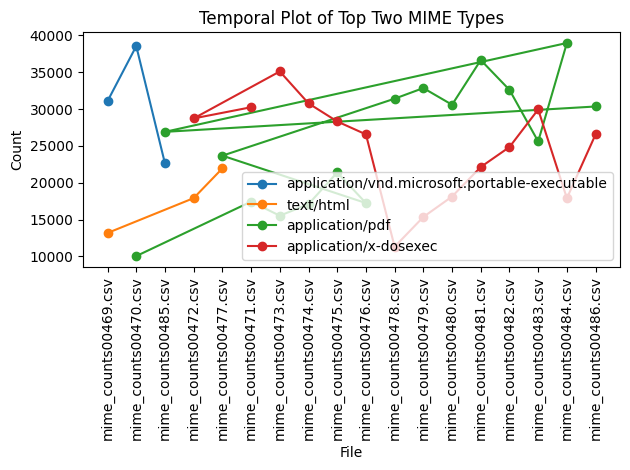

In [5]:
#Temporal plot for the top two common MIME types
for mime_type, data in temporal_data.items():
    # Sort data based on filename
    data = sorted(data, key=lambda x: x[0])

    # Extract filename and count for plotting
    filenames, counts = zip(*data)

    # Plot the temporal trend
    plt.plot(filenames, counts, marker='o', label=mime_type)

plt.title('Temporal Plot of Top Two MIME Types')
plt.xlabel('File')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

# Sort the DataFrame by the 'Total Count' column in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Print the sorted DataFrame in a nicely formatted table
print(mime_totals_df.to_string(index=False))

# Save the sorted DataFrame to a new CSV file
mime_totals_df.to_csv('sorted_mime_counts.csv', index=False)

# Count the number of MIME types that have a count of 1
mime_types_count_1 = mime_totals_df[mime_totals_df['Total Count'] == 1]

# Print the number of MIME types with a count of 1
print(f'Number of MIME types with a count of 1: {len(mime_types_count_1)}')

AttributeError: 'dict' object has no attribute 'sort_values'

Columns in mime_counts00469.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00470.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00471.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00472.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00473.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00474.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00475.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00476.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00477.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00478.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00479.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00480.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00481.csv: ['MIME_type', 'Coun

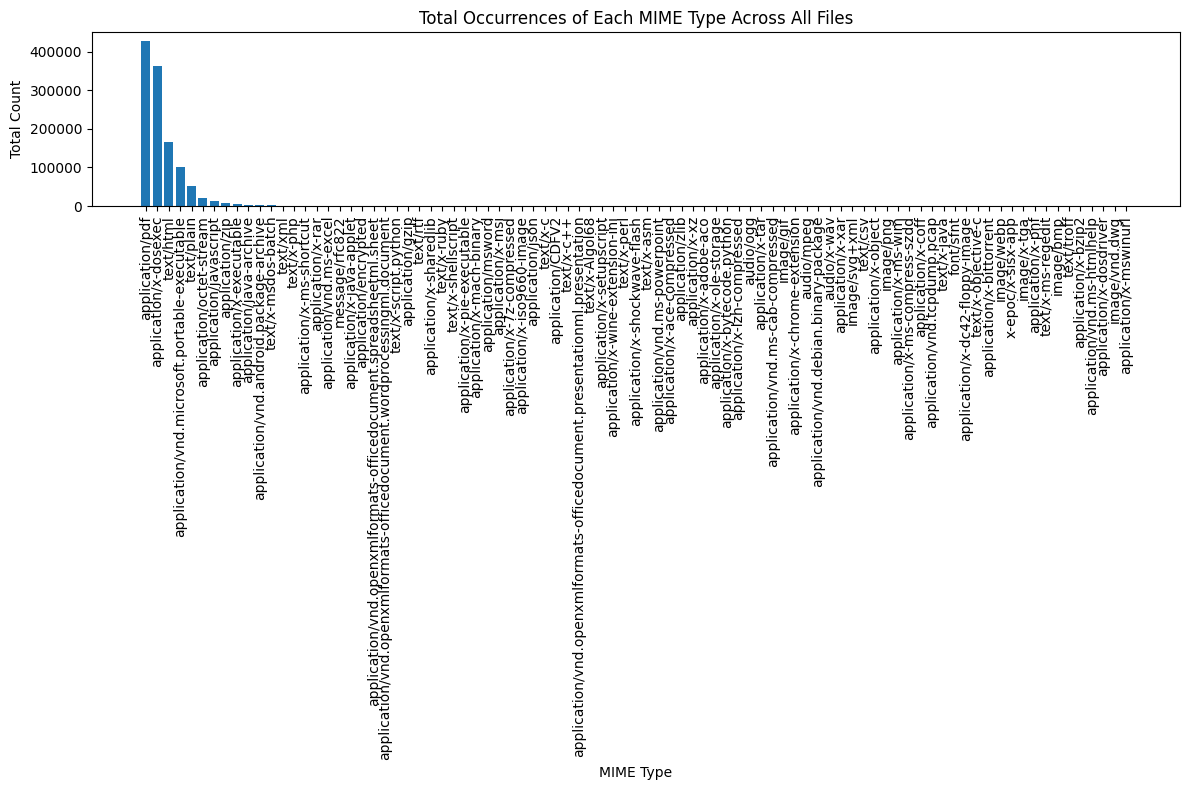

In [ ]:
# Directory containing the mime_counts004xx.csv files
directory = './TypeCounts/'

# Dictionary to store the total count of each MIME type across all files
mime_type_totals = {}

# Function to read a CSV file and return a dataframe
def read_mime_counts(file_path):
    return pd.read_csv(file_path)

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('mime_counts') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = read_mime_counts(file_path)

        # Check column names and print them to understand the format
        print(f"Columns in {filename}: {df.columns.tolist()}")

        # Adjust column names based on the actual column structure
        # Assuming the columns are 'Tipo MIME,Count,Arquivo' in a single string
        # Split the string into separate columns if needed
        if 'Tipo MIME,Count,Arquivo' in df.columns:
            df[['MIME_type', 'Count', 'Arquivo']] = df['Tipo MIME,Count,Arquivo'].str.split(',', expand=True)

        # Convert the 'Count' column to integer
        df['Count'] = df['Count'].astype(int)

        # Accumulate counts for each MIME type
        for index, row in df.iterrows():
            mime_type = row['MIME_type']
            count = row['Count']
            if mime_type not in mime_type_totals:
                mime_type_totals[mime_type] = 0
            mime_type_totals[mime_type] += count

# Convert the accumulated data to a DataFrame for plotting
mime_totals_df = pd.DataFrame(list(mime_type_totals.items()), columns=['MIME Type', 'Total Count'])

# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Plot the bar chart showing the total occurrences of each MIME type
plt.figure(figsize=(12, 8))
plt.bar(mime_totals_df['MIME Type'], mime_totals_df['Total Count'])
plt.title('Total Occurrences of Each MIME Type Across All Files')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Counts from all MIME Types

In [ ]:

# Sort the DataFrame by the 'Total Count' column in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Print the sorted DataFrame in a nicely formatted table
print(mime_totals_df.to_string(index=False))

# Save the sorted DataFrame to a new CSV file
mime_totals_df.to_csv('sorted_mime_counts.csv', index=False)

# Count the number of MIME types that have a count of 1
mime_types_count_1 = mime_totals_df[mime_totals_df['Total Count'] == 1]

# Print the number of MIME types with a count of 1
print(f'Number of MIME types with a count of 1: {len(mime_types_count_1)}')

                                                                MIME Type  Total Count
                                                          application/pdf       428558
                                                    application/x-dosexec       361807
                                                                text/html       166224
                            application/vnd.microsoft.portable-executable       100628
                                                               text/plain        52176
                                                 application/octet-stream        20854
                                                   application/javascript        13383
                                                          application/zip         8944
                                                 application/x-executable         6553
                                                 application/java-archive         3426
                                  applicati

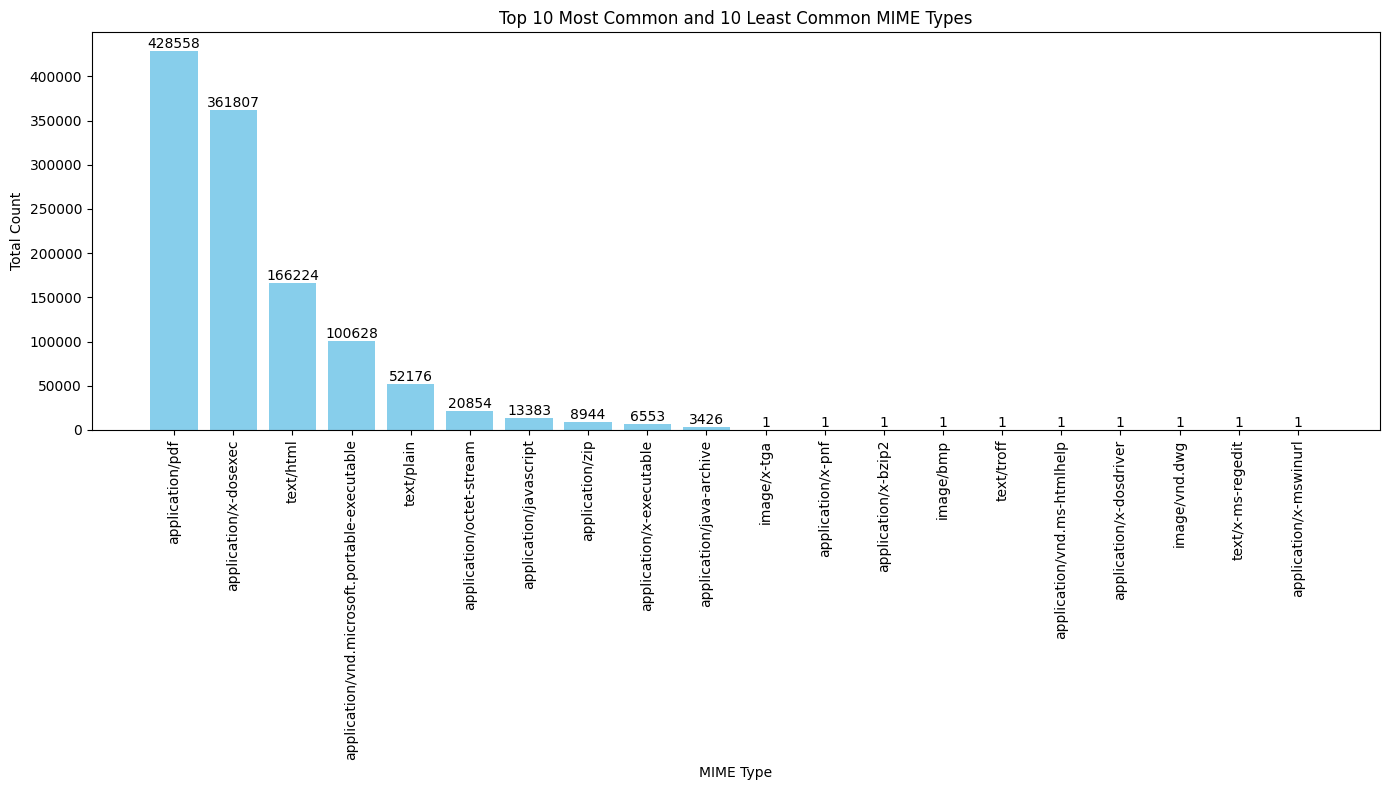

In [ ]:
import matplotlib.pyplot as plt

# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Select the top 10 most common and 10 least common MIME types
top_10 = mime_totals_df.head(10)
bottom_10 = mime_totals_df.tail(10)

# Combine top 10 and bottom 10 into a single DataFrame
combined_df = pd.concat([top_10, bottom_10])

# Plot the bar chart showing the total occurrences for the selected MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(combined_df['MIME Type'], combined_df['Total Count'], color='skyblue')
plt.title('Top 10 Most Common and 10 Least Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


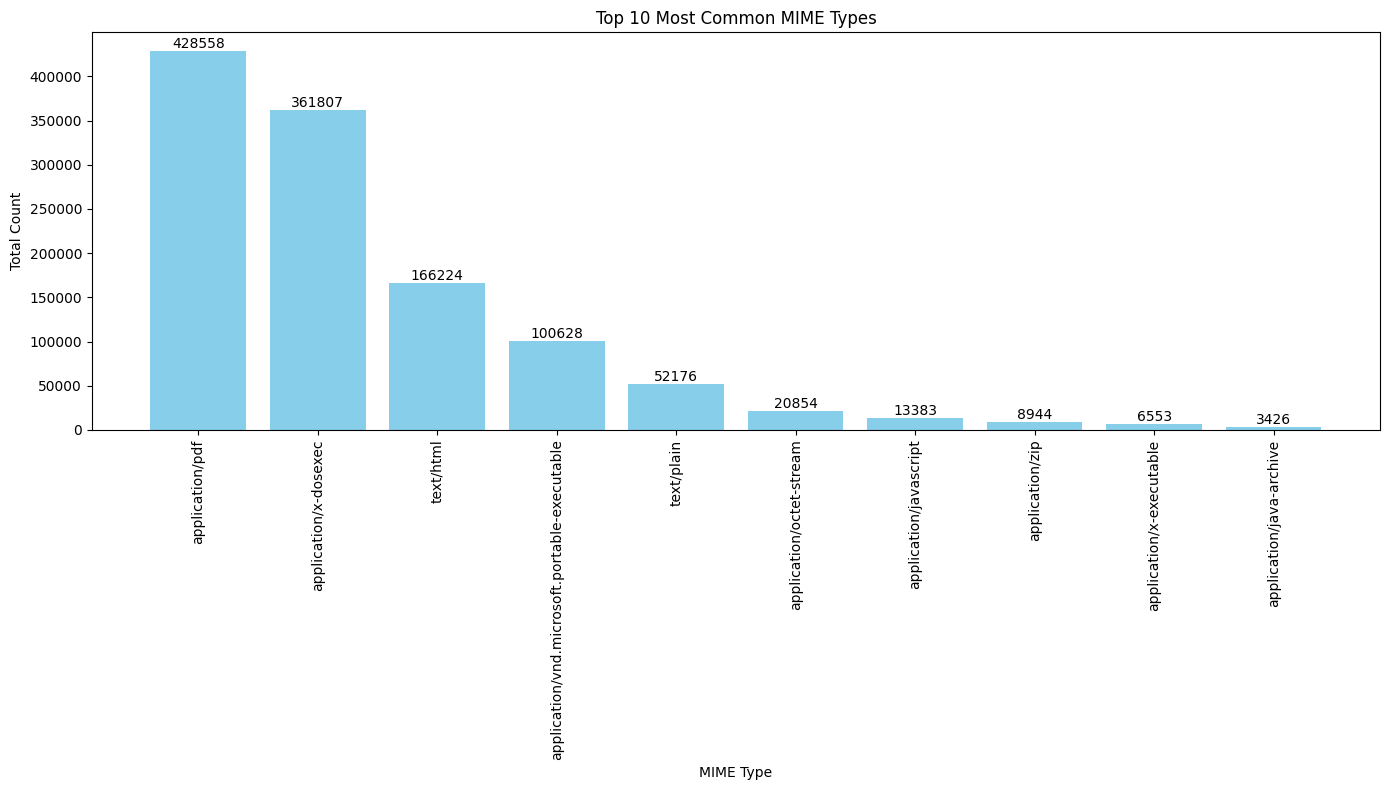

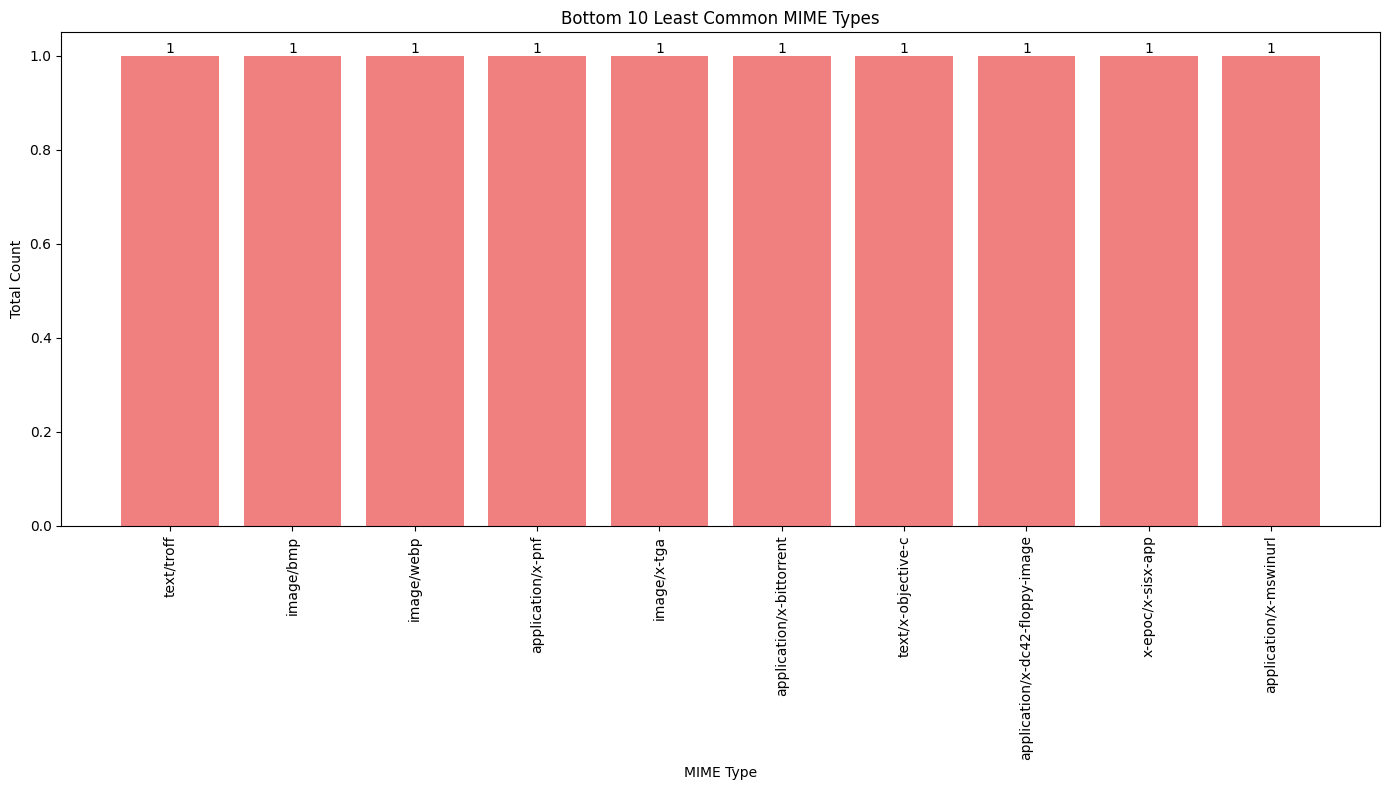

In [ ]:
# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Select the top 10 most common and 10 least common MIME types
top_10 = mime_totals_df.head(10)
bottom_10 = mime_totals_df.tail(10)

# Plot the bar chart for the top 10 most common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue')
plt.title('Top 10 Most Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Plot the bar chart for the bottom 10 least common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(bottom_10['MIME Type'], bottom_10['Total Count'], color='lightcoral')
plt.title('Bottom 10 Least Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_8370/465030062.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_10['MIME Type'], rotation=90)


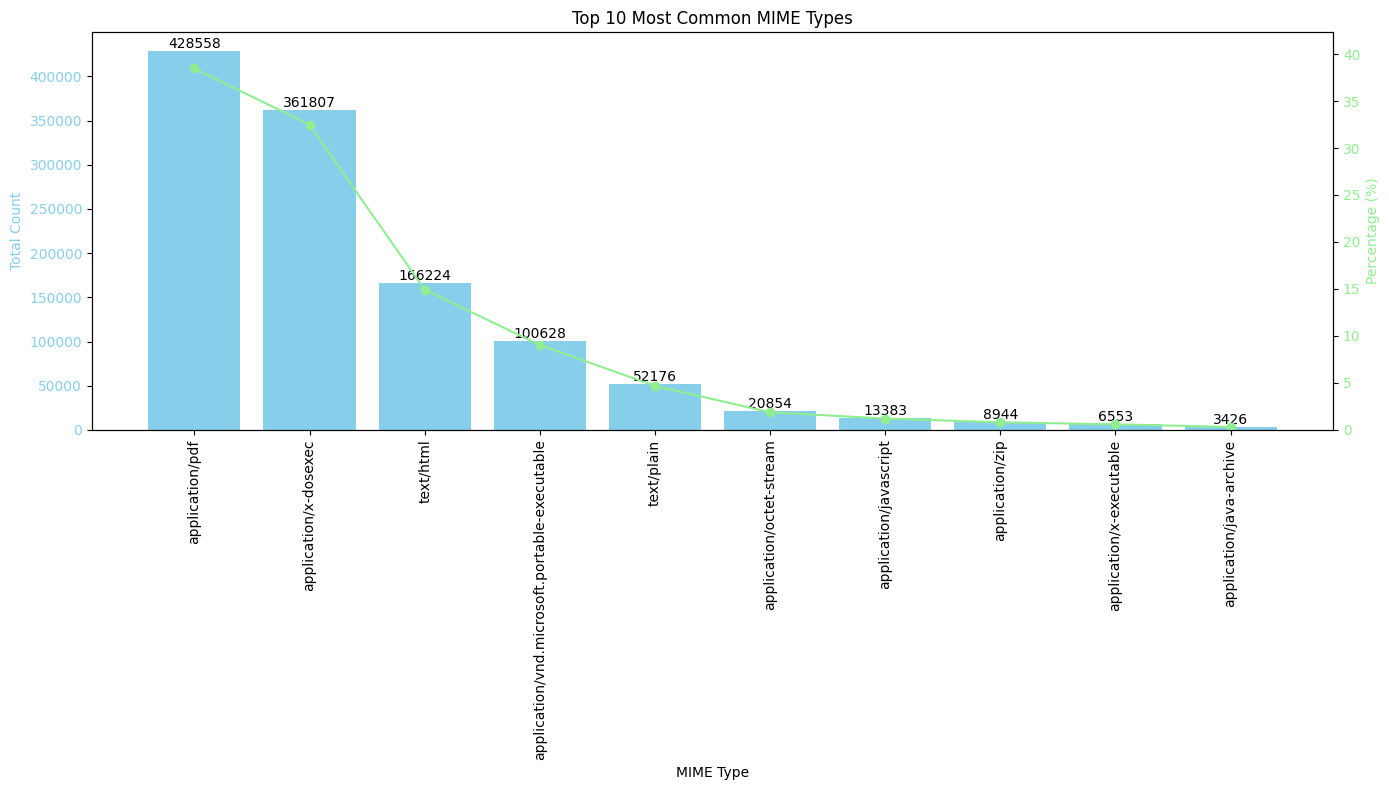

/tmp/ipykernel_8370/465030062.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(bottom_10['MIME Type'], rotation=90)


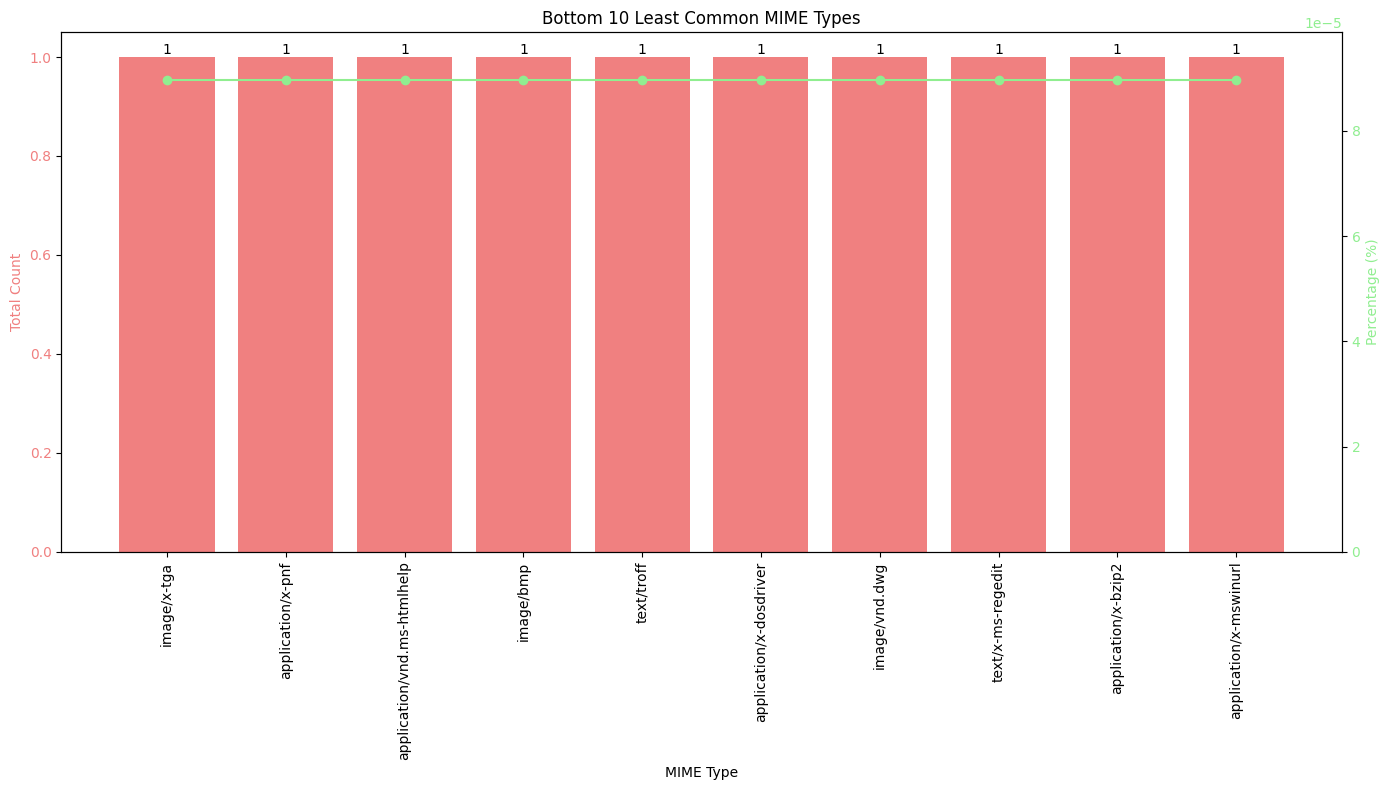

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming mime_totals_df is already defined with 'MIME Type' and 'Total Count'

# Calculate the total number of samples
total_samples = mime_totals_df['Total Count'].sum()

# Calculate the percentage of each MIME type
mime_totals_df['Percentage'] = (mime_totals_df['Total Count'] / 1114112) * 100

# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Select the top 10 most common and 10 least common MIME types
top_10 = mime_totals_df.head(10)
bottom_10 = mime_totals_df.tail(10)

# Plot the bar chart for the top 10 most common MIME types
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot count
bars = ax1.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue', label='Total Count')
ax1.set_title('Top 10 Most Common MIME Types')
ax1.set_xlabel('MIME Type')
ax1.set_ylabel('Total Count', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(top_10['MIME Type'], rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

# Create a second y-axis for percentage
ax2 = ax1.twinx()
ax2.set_ylabel('Percentage (%)', color='lightgreen')
ax2.tick_params(axis='y', labelcolor='lightgreen')

# Plot percentage
ax2.plot(top_10['MIME Type'], top_10['Percentage'], color='lightgreen', marker='o', label='Percentage')
ax2.set_ylim(0, max(top_10['Percentage']) * 1.1)  # Set limits for better visibility

fig.tight_layout()
plt.show()

# Plot the bar chart for the bottom 10 least common MIME types
fig, ax3 = plt.subplots(figsize=(14, 8))

# Plot count
bars_bottom = ax3.bar(bottom_10['MIME Type'], bottom_10['Total Count'], color='lightcoral', label='Total Count')
ax3.set_title('Bottom 10 Least Common MIME Types')
ax3.set_xlabel('MIME Type')
ax3.set_ylabel('Total Count', color='lightcoral')
ax3.tick_params(axis='y', labelcolor='lightcoral')
ax3.set_xticklabels(bottom_10['MIME Type'], rotation=90)

# Add the count value on top of each bar
for bar in bars_bottom:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

# Create a second y-axis for percentage
ax4 = ax3.twinx()
ax4.set_ylabel('Percentage (%)', color='lightgreen')
ax4.tick_params(axis='y', labelcolor='lightgreen')

# Plot percentage
ax4.plot(bottom_10['MIME Type'], bottom_10['Percentage'], color='lightgreen', marker='o', label='Percentage')
ax4.set_ylim(0, max(bottom_10['Percentage']) * 1.1)  # Set limits for better visibility

fig.tight_layout()
plt.show()


In [ ]:
# Assuming mime_totals_df is defined with 'MIME Type', 'Total Count', and 'Percentage'

# Print total count and percentage for the top 10 most common MIME types
print("Top 10 Most Common MIME Types:")
print(f"{'MIME Type':<40} {'Total Count':<15} {'Percentage (%)':<15}")
for index, row in top_10.iterrows():
    print(f"{row['MIME Type']:<40} {row['Total Count']:<15} {row['Percentage']:.2f}")

print("\nBottom 10 Least Common MIME Types:")
print(f"{'MIME Type':<40} {'Total Count':<15} {'Percentage (%)':<15}")
for index, row in bottom_10.iterrows():
    print(f"{row['MIME Type']:<40} {row['Total Count']:<15} {row['Percentage']:.2f}")


Top 10 Most Common MIME Types:
MIME Type                                Total Count     Percentage (%) 
application/pdf                          428558          38.47
application/x-dosexec                    361807          32.47
text/html                                166224          14.92
application/vnd.microsoft.portable-executable 100628          9.03
text/plain                               52176           4.68
application/octet-stream                 20854           1.87
application/javascript                   13383           1.20
application/zip                          8944            0.80
application/x-executable                 6553            0.59
application/java-archive                 3426            0.31

Bottom 10 Least Common MIME Types:
MIME Type                                Total Count     Percentage (%) 
image/x-tga                              1               0.00
application/x-pnf                        1               0.00
application/vnd.ms-htmlhelp        

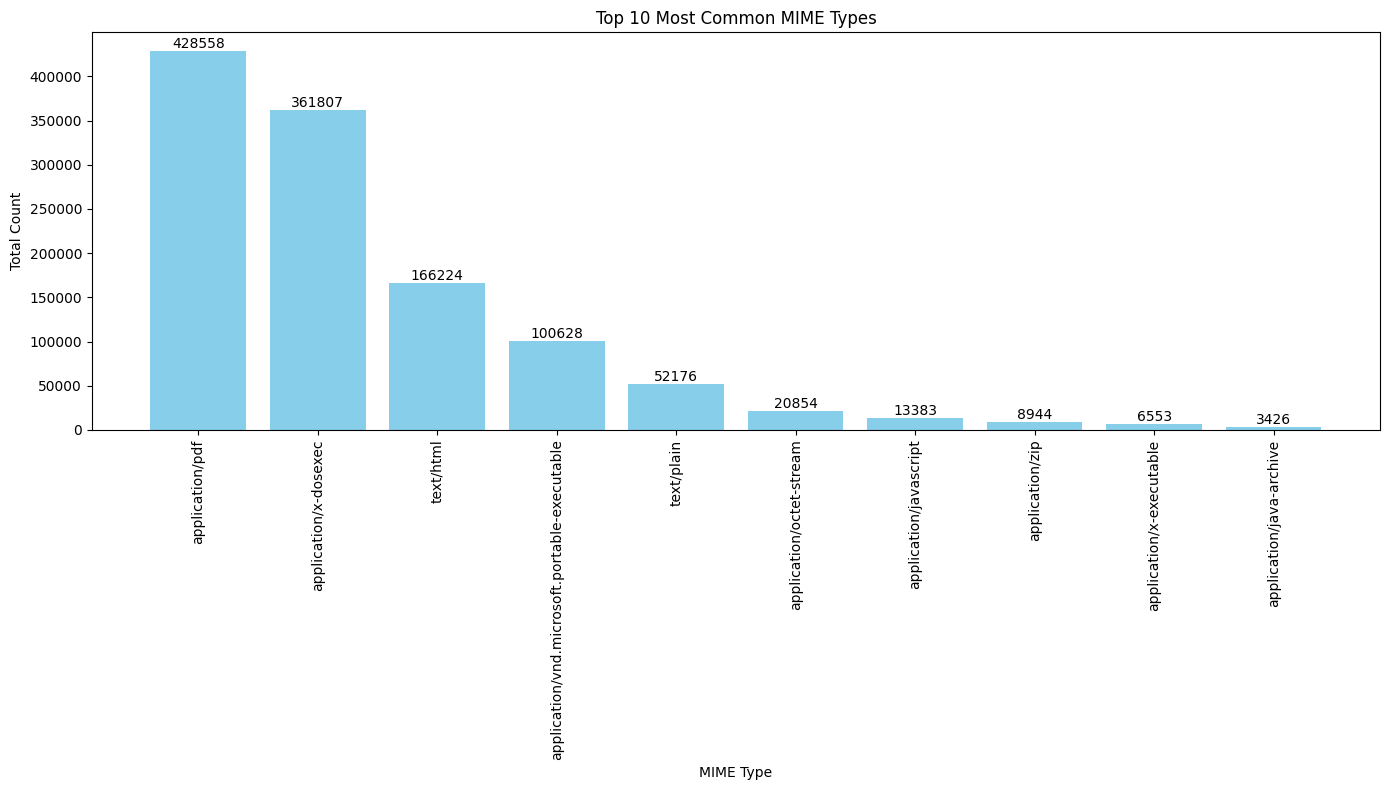

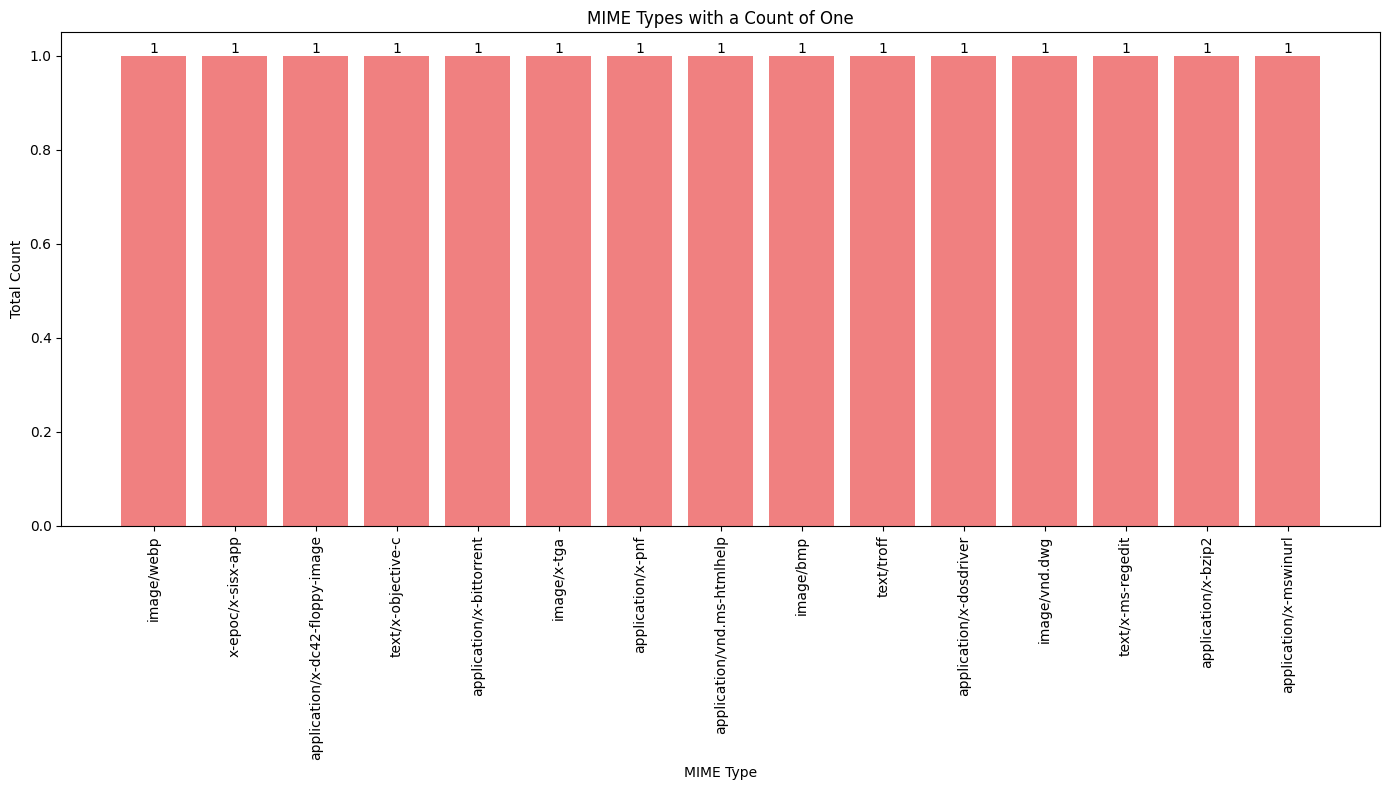

In [ ]:
# Filter the data to select MIME types that have a total count of one
count_one_df = mime_totals_df[mime_totals_df['Total Count'] == 1]

# Plot the bar chart for the top 10 most common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue')
plt.title('Top 10 Most Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Plot the bar chart for MIME types that have a count of one
plt.figure(figsize=(14, 8))
bars = plt.bar(count_one_df['MIME Type'], count_one_df['Total Count'], color='lightcoral')
plt.title('MIME Types with a Count of One')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


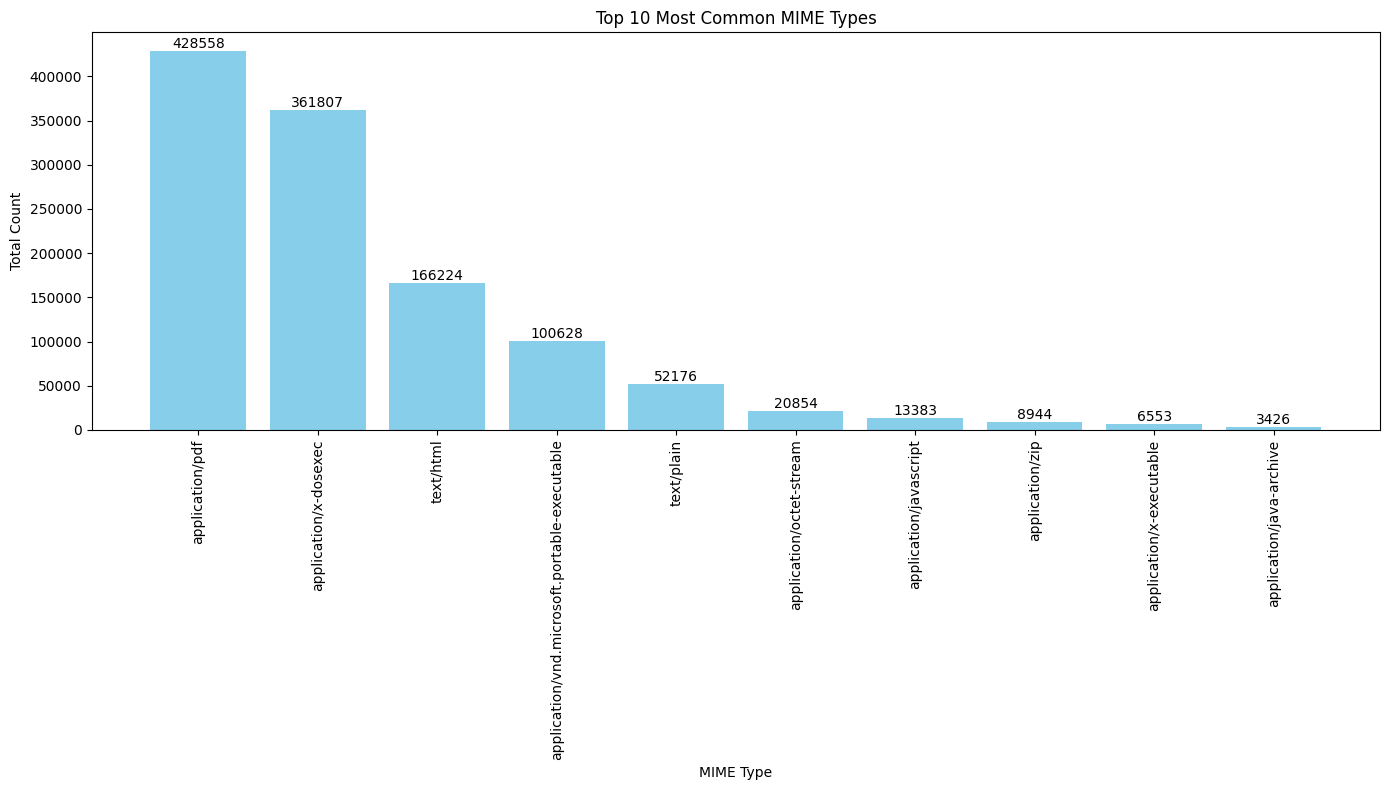

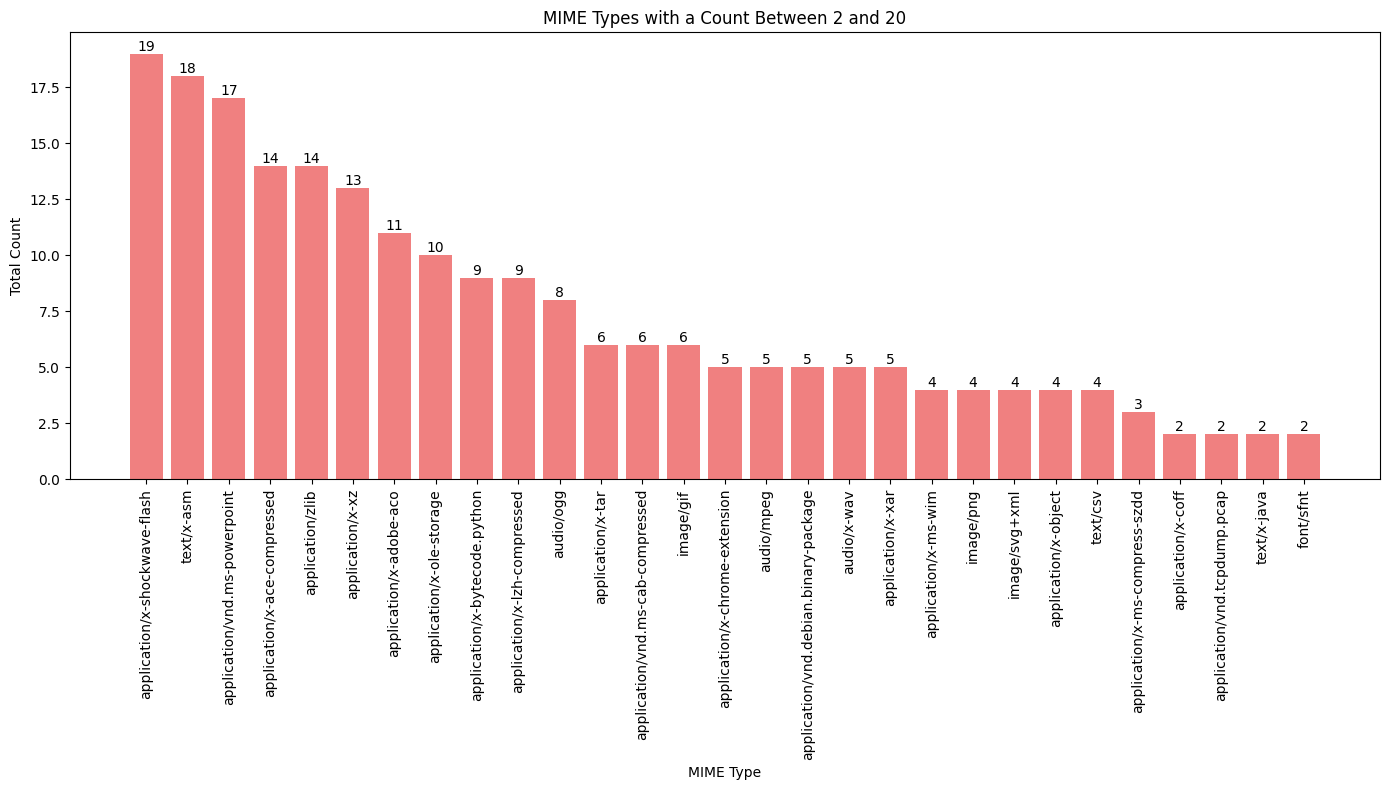

In [ ]:
# Filter the data to select MIME types that have a total count between 2 and 20
count_between_2_and_20_df = mime_totals_df[(mime_totals_df['Total Count'] >= 2) & (mime_totals_df['Total Count'] <= 20)]

# Plot the bar chart for the top 10 most common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue')
plt.title('Top 10 Most Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Plot the bar chart for MIME types with a count between 2 and 20
plt.figure(figsize=(14, 8))
bars = plt.bar(count_between_2_and_20_df['MIME Type'], count_between_2_and_20_df['Total Count'], color='lightcoral')
plt.title('MIME Types with a Count Between 2 and 20')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

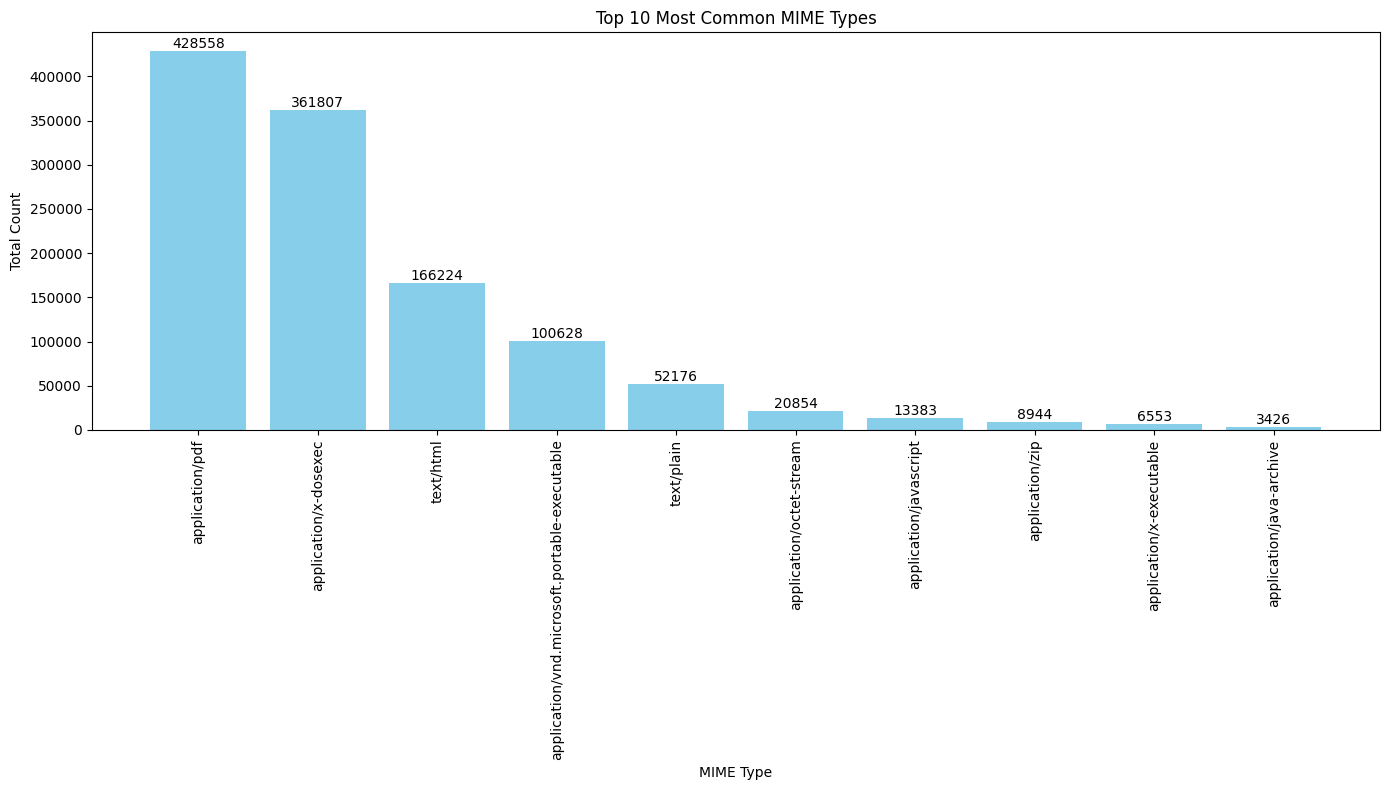

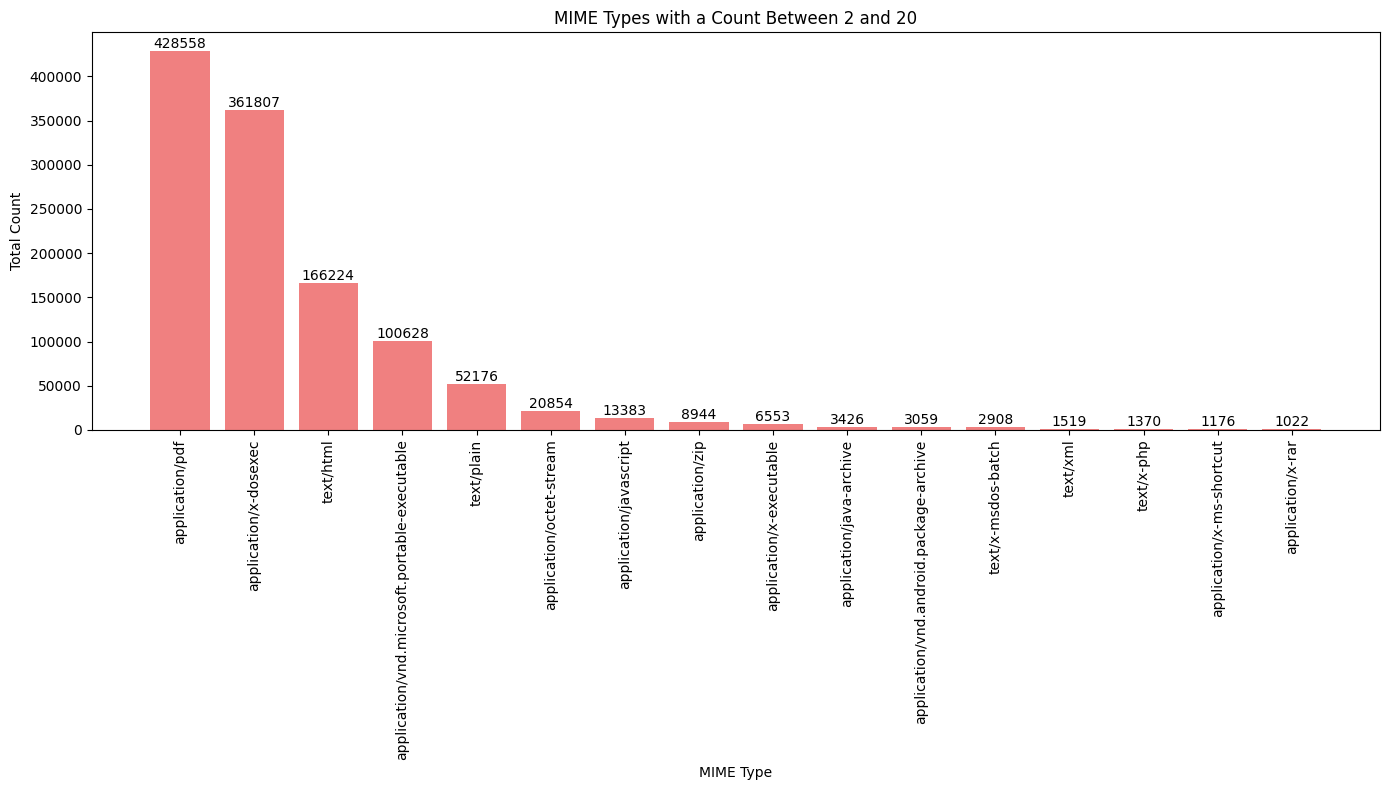

In [ ]:
# Filter the data to select MIME types that have a total count between 2 and 20
count_between_2_and_20_df = mime_totals_df[(mime_totals_df['Total Count'] >= 1000)]

# Plot the bar chart for the top 10 most common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue')
plt.title('Top 10 Most Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Plot the bar chart for MIME types with a count between 2 and 20
plt.figure(figsize=(14, 8))
bars = plt.bar(count_between_2_and_20_df['MIME Type'], count_between_2_and_20_df['Total Count'], color='lightcoral')
plt.title('MIME Types with a Count Between 2 and 20')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()